In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

In [15]:
df=pd.read_csv("/content/support_tickets.csv")

In [16]:
# Keep rows with both ticket text and category
df_clean = df.dropna(subset=["text", "label"]).copy()

# Remove leading/trailing spaces, then discard blank values
df_clean["text"] = df_clean["text"].astype(str).str.strip()
df_clean["label"] = df_clean["label"].astype(str).str.strip()
df_clean = df_clean[(df_clean["text"] != "") & (df_clean["label"] != "")]

# Check whether identical texts have conflicting categories
labels_per_text = df_clean.groupby("text")["label"].nunique()
conflicting_texts = labels_per_text[labels_per_text > 1]

print("Texts with conflicting labels:", len(conflicting_texts))

if not conflicting_texts.empty:
    display(df_clean[df_clean["text"].isin(conflicting_texts.index)].head(20))
    raise ValueError("Investigate conflicting labels before deduplicating.")

# Remove exact duplicate texts
df_clean = df_clean.drop_duplicates(subset="text").copy()

print("Rows after cleaning and deduplication:", len(df_clean))
print("\nCategory counts:")
print(df_clean["label"].value_counts())

Texts with conflicting labels: 0
Rows after cleaning and deduplication: 826

Category counts:
label
feature_request    234
bug                227
general_inquiry    155
billing_issue      135
account_problem     75
Name: count, dtype: int64


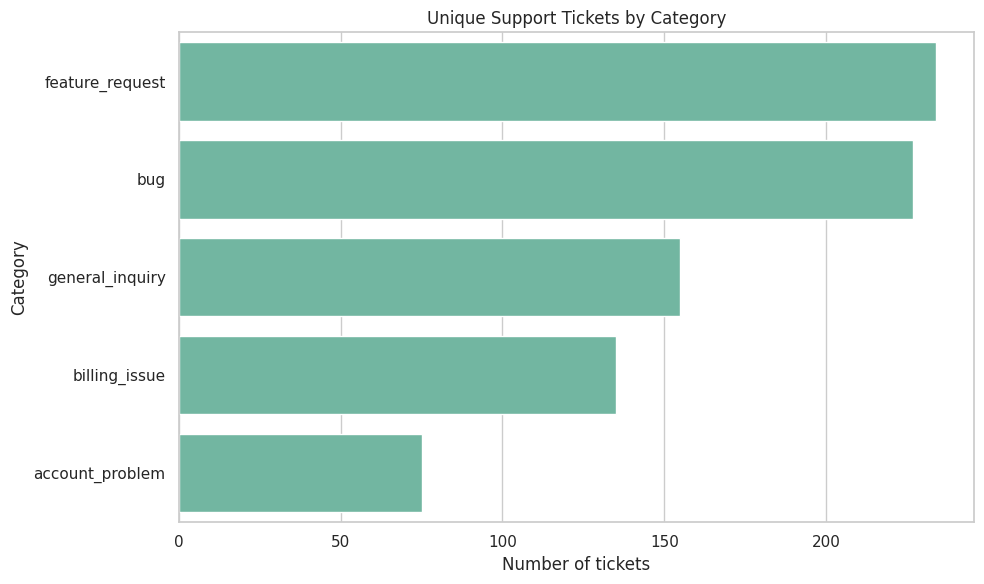

In [17]:
plt.figure(figsize=(10, 6))

order = df_clean["label"].value_counts().index

sns.countplot(
    data=df_clean,
    y="label",
    order=order,
)

plt.title("Unique Support Tickets by Category")
plt.xlabel("Number of tickets")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

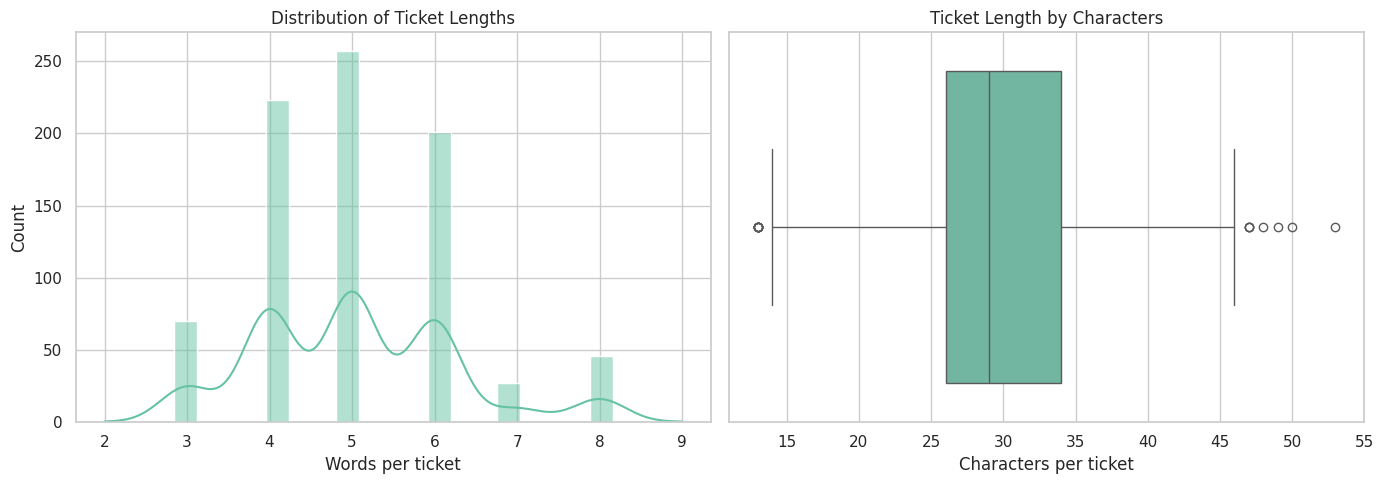

Median words per ticket: 5.0


In [18]:
df_clean["word_count"] = df_clean["text"].str.split().str.len()
df_clean["character_count"] = df_clean["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_clean, x="word_count", bins=25, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Ticket Lengths")
axes[0].set_xlabel("Words per ticket")

sns.boxplot(data=df_clean, x="character_count", ax=axes[1])
axes[1].set_title("Ticket Length by Characters")
axes[1].set_xlabel("Characters per ticket")

plt.tight_layout()
plt.show()

print("Median words per ticket:", df_clean["word_count"].median())

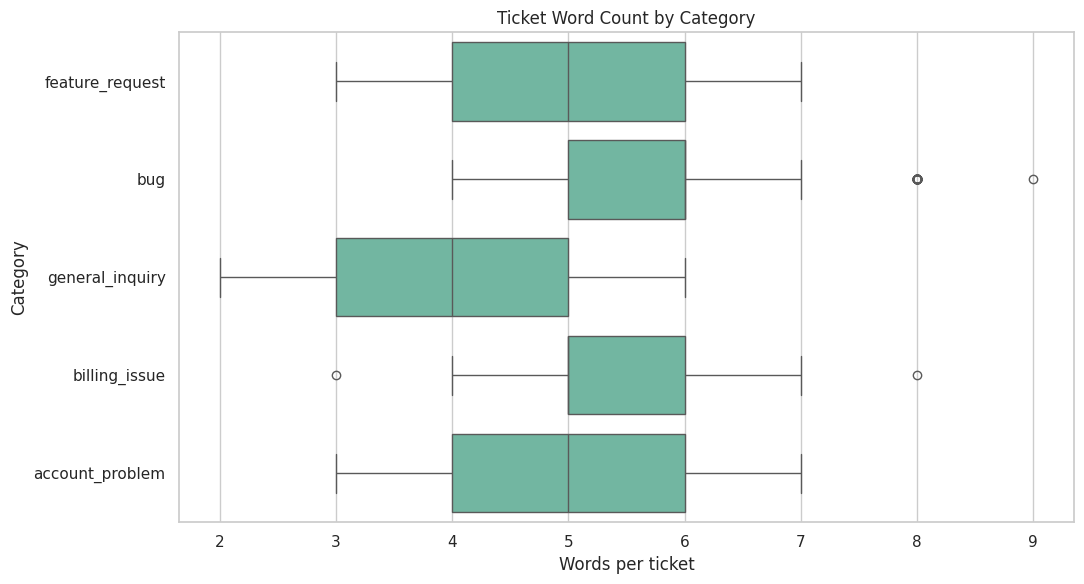

In [19]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df_clean,
    x="word_count",
    y="label",
    order=order,
)

plt.title("Ticket Word Count by Category")
plt.xlabel("Words per ticket")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

**bold text**
#Visualization Summary
The charts provide an overview of the cleaned support-ticket dataset, with incomplete rows and exact duplicate texts removed.

Tickets by category: Shows how many tickets belong to each category. Larger counts indicate categories with more examples in the dataset.
Ticket length distribution: Shows how many words tickets typically contain and whether very short or long tickets are common.
Ticket length by category: Compares word counts across categories. The median line shows the typical length for each category, while the box and whiskers show how much lengths vary.
 These charts describe the dataset and help identify imbalances or unusual patterns. They do not measure the classifier’s performance. **bold text**